# PASO 1: CARGA Y PREPARACIÓN PARA LA IA

In [13]:
# PASO 1: CARGA Y PREPARACIÓN PARA LA IA

import pandas as pd
from sklearn.preprocessing import LabelEncoder

# 1. Cargamos el dataset que limpiamos 
df = pd.read_csv('../data/processed/viviendas_sevilla_limpio.csv')

# 2. Borramos 'price_m2' antes de entrenar (porque sería trampa para la IA)
if 'price_m2' in df.columns:
    df = df.drop(columns=['price_m2'])

# 3. Traductor de palabras a números (Creamos un diccionario de encoders)
diccionario_encoders = {}
columnas_texto = ['loc_city', 'loc_district', 'house_type']

for col in columnas_texto:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    diccionario_encoders[col] = le # Guardamos el traductor específico de esta columna
    print(f"✅ Columna '{col}' traducida a números.")

# 4. Comprobamos que todo el dataset es ahora numérico
print("\n--- RESUMEN DEL DATASET PARA LA IA ---")
print(df.info())
display(df.head())

✅ Columna 'loc_city' traducida a números.
✅ Columna 'loc_district' traducida a números.
✅ Columna 'house_type' traducida a números.

--- RESUMEN DEL DATASET PARA LA IA ---
<class 'pandas.DataFrame'>
RangeIndex: 4247 entries, 0 to 4246
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   price                4247 non-null   int64
 1   m2_real              4247 non-null   int64
 2   room_num             4247 non-null   int64
 3   bath_num             4247 non-null   int64
 4   loc_city             4247 non-null   int64
 5   loc_district         4247 non-null   int64
 6   house_type           4247 non-null   int64
 7   balcony              4247 non-null   int64
 8   garage               4247 non-null   int64
 9   swimming_pool        4247 non-null   int64
 10  terrace              4247 non-null   int64
 11  storage_room         4247 non-null   int64
 12  lift                 4247 non-null   int64
 13  garden 

,price,m2_real,room_num,bath_num,loc_city,loc_district,house_type,balcony,garage,swimming_pool,terrace,storage_room,lift,garden,is_needs_renovating,is_new_development
0,1355000,519,5,6,25,785,1,1,1,1,1,1,0,1,0,0
1,1300000,670,5,4,25,781,1,0,0,1,1,0,0,1,0,0
2,1250000,709,5,5,25,785,6,0,1,1,0,0,0,1,0,0
3,1000000,500,4,1,3,521,1,1,1,0,0,0,0,0,1,0
4,780300,782,1,1,10,769,6,0,1,0,0,0,0,0,1,0


# PASO 2: SEPARACIÓN DE DATOS

In [14]:
# PASO 2: SEPARACIÓN DE DATOS

from sklearn.model_selection import train_test_split

# 1. Definimos la 'X' (lo que usamos para predecir) y la 'y' (lo que queremos predecir)
X = df.drop(columns=['price'])  # Coge automáticamente TODAS las columnas (incluidas las de reforma)
y = df['price']                 # Solo la columna del precio

# 2. Dividimos el dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\n📊 Datos totales: {len(df)}")
print(f"📚 Datos para que la IA estudie (entrenamiento): {len(X_train)}")
print(f"📝 Datos para examinar a la IA (prueba): {len(X_test)}")


📊 Datos totales: 4247
📚 Datos para que la IA estudie (entrenamiento): 3397
📝 Datos para examinar a la IA (prueba): 850


# PASO 3: ELECCIÓN DEL MODELO Y ENTRENAMIENTO

In [15]:
# PASO 3: ELECCIÓN DEL MODELO Y ENTRENAMIENTO

from sklearn.ensemble import RandomForestRegressor

# 1. Creamos el modelo (el "bosque" con 100 árboles)
modelo_viviendas = RandomForestRegressor(n_estimators=100, random_state=42)

# 2. ENTRENAMIENTO: Aquí es donde la IA empieza a estudiar
print("\n⏳ Entrenando a la IA (esto puede tardar unos segundos)...")
modelo_viviendas.fit(X_train, y_train)

print("✅ ¡Entrenamiento completado! El modelo ya ha buscado patrones en Sevilla.")


⏳ Entrenando a la IA (esto puede tardar unos segundos)...
✅ ¡Entrenamiento completado! El modelo ya ha buscado patrones en Sevilla.


# PASO 4: EVALUACIÓN DEL MODELO

In [16]:
# PASO 4: EVALUACIÓN DEL MODELO

from sklearn.metrics import mean_absolute_error, r2_score

# 1. La IA hace el examen
predicciones = modelo_viviendas.predict(X_test)

# 2. Comparamos las respuestas de la IA con la realidad
mae = mean_absolute_error(y_test, predicciones)
r2 = r2_score(y_test, predicciones)

print(f"\n📉 Error Medio (MAE): {mae:,.2f} €")
print(f"📈 Puntuación de precisión (R2): {r2:.4f}")

# 3. Vamos a ver un ejemplo real de las primeras 5 casas del examen
print("\n--- COMPARATIVA: REAL VS PREDICCIÓN ---")
comparativa = pd.DataFrame({'Precio Real': y_test, 'Predicción IA': predicciones}).head()
display(comparativa)


📉 Error Medio (MAE): 29,873.54 €
📈 Puntuación de precisión (R2): 0.8177

--- COMPARATIVA: REAL VS PREDICCIÓN ---


,Precio Real,Predicción IA
3628,70000,109318.880000
2016,140000,156526.300000
990,209900,103038.440000
3160,87000,95047.626667
120,390000,448929.000000


# PASO 5: ¿QUÉ ES LO MÁS IMPORTANTE PARA EL PRECIO?

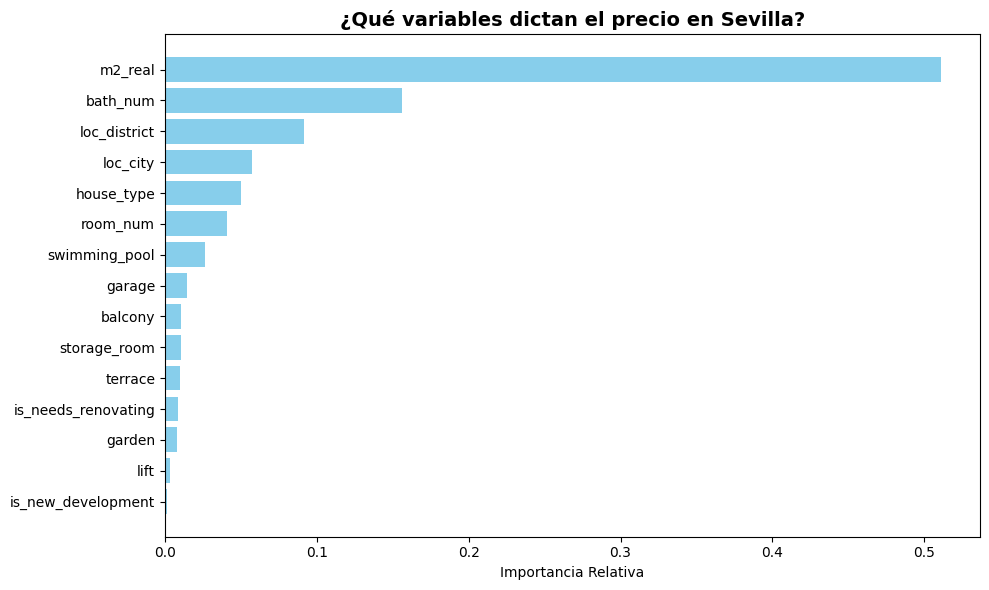

In [ ]:
# PASO 5: ¿QUÉ ES LO MÁS IMPORTANTE PARA EL PRECIO?

import matplotlib.pyplot as plt
import numpy as np

# 1. Sacamos la importancia de cada variable
importancias = modelo_viviendas.feature_importances_
columnas = X.columns
indices = np.argsort(importancias)

# 2. Creamos el gráfico
plt.figure(figsize=(10, 6))
plt.title('¿Qué variables dictan el precio en Sevilla?', fontsize=14, fontweight='bold')
plt.barh(range(len(indices)), importancias[indices], color='skyblue', align='center')
plt.yticks(range(len(indices)), [columnas[i] for i in indices])
plt.xlabel('Importancia Relativa')
plt.tight_layout()
plt.show()

# PASO 6: GUARDADO DEL DATASET PROCESADO

In [18]:
# PASO 6: GUARDADO DEL DATASET PROCESADO

import joblib
import os

# 1. Creamos la carpeta 'models' si no existe
if not os.path.exists('../models'):
    os.makedirs('../models')

# 2. Guardamos el modelo entrenado
joblib.dump(modelo_viviendas, '../models/modelo_casas_sevilla.pkl')

# 3. Guardamos el diccionario de encoders
joblib.dump(diccionario_encoders, '../models/diccionario_encoders.pkl')

print("\n💾 ¡Modelo y Encoders guardados con éxito en la carpeta /models!")


💾 ¡Modelo y Encoders guardados con éxito en la carpeta /models!
